In [ ]:
'''
Here we compared the fitness dynamics of different MIC chromosome fragmentation level under population size N = 20 during 10K 
generations.

The reproduction mode is having sex (random mating) every 100 generations, and the MIC fragmentation level is set to have 1, 5, 
10, 20 and 50 loci per MIC chromosome (with a total number of 100 loci).

Also, the fitness dynamics of having 1 locus per MIC chromosome in new model is compared with our original WF model, to make sure
that the results are consistent.

'''

In [1]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
%matplotlib inline

In [2]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 20})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

In [3]:
generation_list = []

for i in range(10002):
    generation_list.append(i)
    
print(len(generation_list))

10002


In [5]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180813_Multiple loci in Germ Chromosome_Original Model\Data\No Crossover\RM E100_GMU =0.1")

In [6]:
file_20 = ['Fitness_WF_RM_20_E100_GermL_1PerCh_FirstFragThenAmp.csv','Fitness_WF_RM_20_E100_GermL_5PerCh_FirstFragThenAmp.csv', \
           'Fitness_WF_RM_20_E100_GermL_10PerCh_FirstFragThenAmp.csv','Fitness_WF_RM_20_E100_GermL_20PerCh_FirstFragThenAmp.csv',\
           'Fitness_WF_RM_20_E100_GermL_50PerCh_FirstFragThenAmp.csv', 'Fitness_WF_RM_20_E100_GermL_100PerCh_FirstFragThenAmp.csv']

In [7]:
f20_fit_mean = []
f20_fit_std = []

for i in file_20:
    f = pd.read_csv(i,dtype=str)
    
    fit_mean = []
    fit_std = []
       
    fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
    fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
        
    f20_fit_mean.append(fit_mean)
    f20_fit_std.append(fit_std)

Fitness comparison between different fragmentation level

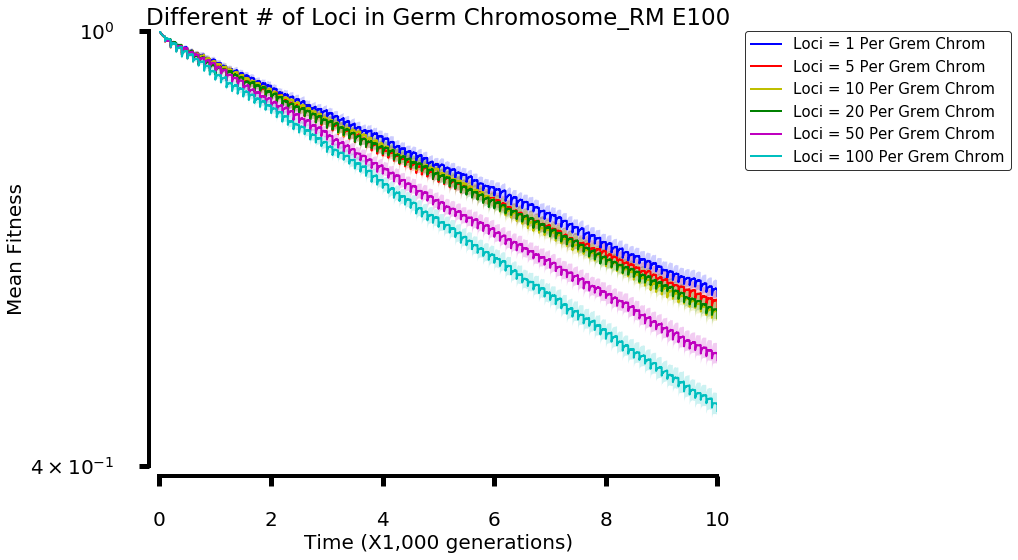

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,10000)


t = generation_list

a = f20_fit_mean[0]  # Amito
error_a = list(1.96* np.array(f20_fit_std[0])/((500)**0.5))

b = f20_fit_mean[1]  # Mito
error_b = list(1.96* np.array(f20_fit_std[1])/((500)**0.5))


c = f20_fit_mean[2] # RM_Every G
error_c = list(1.96* np.array(f20_fit_std[2])/((500)**0.5))


d = f20_fit_mean[3] # RM_Every 100G
error_d = list(1.96* np.array(f20_fit_std[3])/((500)**0.5))

e = f20_fit_mean[4] # RM_Every 100G
error_e = list(1.96* np.array(f20_fit_std[4])/((500)**0.5))

f = f20_fit_mean[5] # RM_Every 100G
error_f = list(1.96* np.array(f20_fit_std[5])/((500)**0.5))


ax.set_title('Different # of Loci in Germ Chromosome_RM E100', fontsize =23)
ax.set_xlabel('Time (X1,000 generations)', fontsize =20)
ax.set_ylabel('Mean Fitness', fontsize =20)

ax.set_yscale('log')

ax.plot(t,a,'b', label = 'Loci = 1 Per Grem Chrom',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.2, facecolor='b')

ax.plot(t,b,'r', label = 'Loci = 5 Per Grem Chrom', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.2, facecolor='r')

ax.plot(t,c,'y', label = 'Loci = 10 Per Grem Chrom', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.2, facecolor='y')

ax.plot(t,d,'g', label = 'Loci = 20 Per Grem Chrom', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(d)- np.array(error_d), np.array(d)+ np.array(error_d), alpha =0.2, facecolor='g')

ax.plot(t,e,'m', label = 'Loci = 50 Per Grem Chrom', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(e)- np.array(error_e), np.array(e)+ np.array(error_e), alpha =0.2, facecolor='m')

ax.plot(t,f,'c', label = 'Loci = 100 Per Grem Chrom', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(f)- np.array(error_f), np.array(f)+ np.array(error_f), alpha =0.2, facecolor='c')

ax.minorticks_off()


legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
frame = legend.get_frame()
frame.set_edgecolor('black')

extraticks=[0.4]
ax.set_yticks(list(ax.get_yticks()) + extraticks)
ax.set_ylim(4*10**(-1), 1)


plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

Comparison with the results of our previous model

In [9]:
f1 = pd.read_csv('Fitness_WF_RM_20_E100_NewSex.csv',dtype=str)
    
f1_fit_mean = []
f1_fit_std = []
       
f1_fit_mean.extend(list(pd.Series(f1.meanFit,dtype=float)))
f1_fit_std.extend(list(pd.Series(f1.PopMeanFit_STD,dtype=float)))     

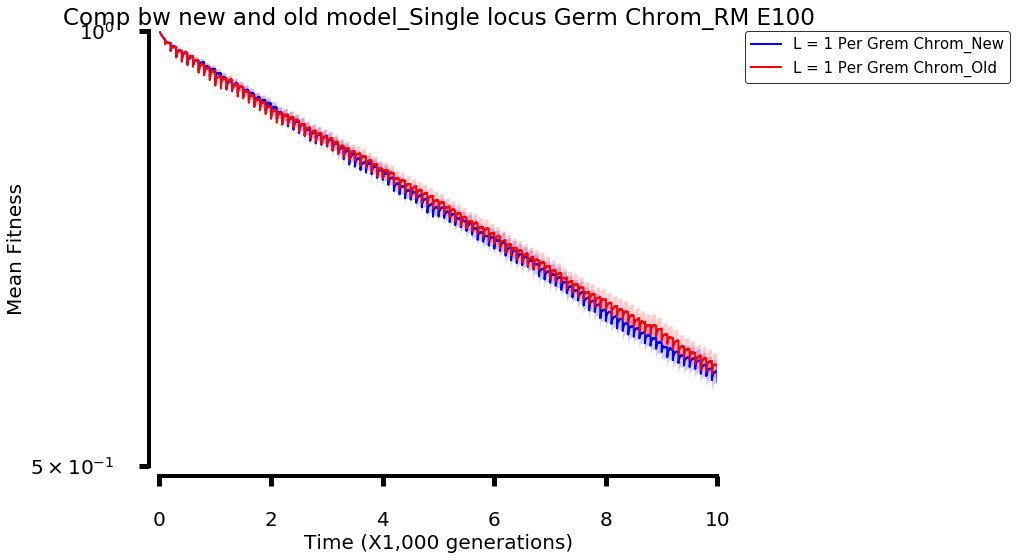

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
publication_figure(ax)

t = generation_list

a = f20_fit_mean[0]  # Amito
error_a = list(1.96* np.array(f20_fit_std[0])/((500)**0.5))

b = f1_fit_mean 
error_b = list(1.96* np.array(f1_fit_std)/((500)**0.5))


ax.set_title('Comp bw new and old model_Single locus Germ Chrom_RM E100', fontsize =23)
ax.set_xlabel('Time (X1,000 generations)', fontsize =20)
ax.set_ylabel('Mean Fitness', fontsize =20)

ax.set_yscale('log')

ax.plot(t,a,'b', label = 'L = 1 Per Grem Chrom_New',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.2, facecolor='b')

ax.plot(t,b,'r', label = 'L = 1 Per Grem Chrom_Old', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.2, facecolor='r')


ax.minorticks_off()


legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
frame = legend.get_frame()
frame.set_edgecolor('black')

extraticks=[0.5]
ax.set_yticks(list(ax.get_yticks()) + extraticks)
ax.set_ylim(5*10**(-1), 1)
ax.set_xlim(0, 10000)


plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

Final fitness after 10K generations

In [11]:
for i in range(6):
    print f20_fit_mean[i][-1]

0.572146857787
0.557919979043
0.544645465732
0.546161122896
0.499645413709
0.448980863441


In [12]:
for i in range(6):
    print 1.96* np.array(f20_fit_std[i][-1])/((500)**0.5)

0.0110552873458
0.0111402041074
0.0111386969137
0.0109747558907
0.0109025775862
0.0101858556263


In [13]:
for i in range(6):
    print f20_fit_mean[i][-1] - 1.96* np.array(f20_fit_std[i][-1])/((500)**0.5)

0.561091570441
0.546779774935
0.533506768818
0.535186367006
0.488742836123
0.438795007814


In [15]:
for i in range(6):
    print f20_fit_mean[i][-1] + 1.96* np.array(f20_fit_std[i][-1])/((500)**0.5)

0.583202145133
0.56906018315
0.555784162645
0.557135878787
0.510547991295
0.459166719067
